# Project 01: World Happiness Report 2023

Анализ факторов, связанных с уровнем счастья стран мира.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
data_path = Path("data/WHR2023.csv")
raw_data = pd.read_csv(data_path)
raw_data.head()

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.804,0.036,7.875,7.733,10.792,0.969,71.150,0.961,-0.019,0.182,1.778,1.888,1.585,0.535,0.772,0.126,0.535,2.363
1,Denmark,7.586,0.041,7.667,7.506,10.962,0.954,71.250,0.934,0.134,0.196,1.778,1.949,1.548,0.537,0.734,0.208,0.525,2.084
2,Iceland,7.530,0.049,7.625,7.434,10.896,0.983,72.050,0.936,0.211,0.668,1.778,1.926,1.620,0.559,0.738,0.250,0.187,2.250
3,Israel,7.473,0.032,7.535,7.411,10.639,0.943,72.697,0.809,-0.023,0.708,1.778,1.833,1.521,0.577,0.569,0.124,0.158,2.691
4,Netherlands,7.403,0.029,7.460,7.346,10.942,0.930,71.550,0.887,0.213,0.379,1.778,1.942,1.488,0.545,0.672,0.251,0.394,2.110


In [3]:
selected_columns = [
    "Country name",
    "Ladder score",
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption",
    "Dystopia + residual",
]

data = raw_data[selected_columns].copy()
data.columns = [
    "country",
    "ladder_score",
    "logged_gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom_to_make_life_choices",
    "generosity",
    "perceptions_of_corruption",
    "dystopia_residual",
]

data.head()

,country,ladder_score,logged_gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,dystopia_residual
0,Finland,7.804,10.792,0.969,71.150,0.961,-0.019,0.182,2.363
1,Denmark,7.586,10.962,0.954,71.250,0.934,0.134,0.196,2.084
2,Iceland,7.530,10.896,0.983,72.050,0.936,0.211,0.668,2.250
3,Israel,7.473,10.639,0.943,72.697,0.809,-0.023,0.708,2.691
4,Netherlands,7.403,10.942,0.930,71.550,0.887,0.213,0.379,2.110


In [4]:
quality_table = pd.DataFrame(
    {
        "missing_values": data.isna().sum(),
        "missing_share": data.isna().mean(),
        "unique_values": data.nunique(),
    }
)
quality_table

,missing_values,missing_share,unique_values
country,0,0.0000,137
ladder_score,0,0.0000,134
logged_gdp_per_capita,0,0.0000,135
social_support,0,0.0000,116
healthy_life_expectancy,1,0.0073,125
freedom_to_make_life_choices,0,0.0000,117
generosity,0,0.0000,122
perceptions_of_corruption,0,0.0000,115
dystopia_residual,1,0.0073,133


In [5]:
data = data.dropna().copy()
numeric_columns = [column for column in data.columns if column != "country"]
summary_table = data[numeric_columns].describe().T
summary_table

,count,mean,std,min,25%,50%,75%,max
ladder_score,136.0,5.5444,1.1428,1.859,4.7025,5.6935,6.3425,7.804
logged_gdp_per_capita,136.0,9.4552,1.2101,5.527,8.5872,9.5745,10.5403,11.660
social_support,136.0,0.7986,0.1296,0.341,0.7210,0.8265,0.8960,0.983
healthy_life_expectancy,136.0,64.9676,5.7504,51.530,60.6485,65.8375,69.4125,77.280
freedom_to_make_life_choices,136.0,0.7881,0.1125,0.382,0.7262,0.8010,0.8748,0.961
generosity,136.0,0.0236,0.1416,-0.254,-0.0710,0.0020,0.1175,0.531
perceptions_of_corruption,136.0,0.7246,0.1774,0.146,0.6660,0.7725,0.8460,0.929
dystopia_residual,136.0,1.7778,0.5044,-0.110,1.5553,1.8485,2.0787,2.955


In [6]:
top_bottom_table = pd.concat(
    [
        data.nlargest(10, "ladder_score")[["country", "ladder_score"]].assign(group="top_10"),
        data.nsmallest(10, "ladder_score")[["country", "ladder_score"]].assign(group="bottom_10"),
    ],
    ignore_index=True,
)
top_bottom_table

,country,ladder_score,group
0,Finland,7.804,top_10
1,Denmark,7.586,top_10
2,Iceland,7.530,top_10
3,Israel,7.473,top_10
4,Netherlands,7.403,top_10
5,Sweden,7.395,top_10
6,Norway,7.315,top_10
7,Switzerland,7.240,top_10
8,Luxembourg,7.228,top_10
9,New Zealand,7.123,top_10


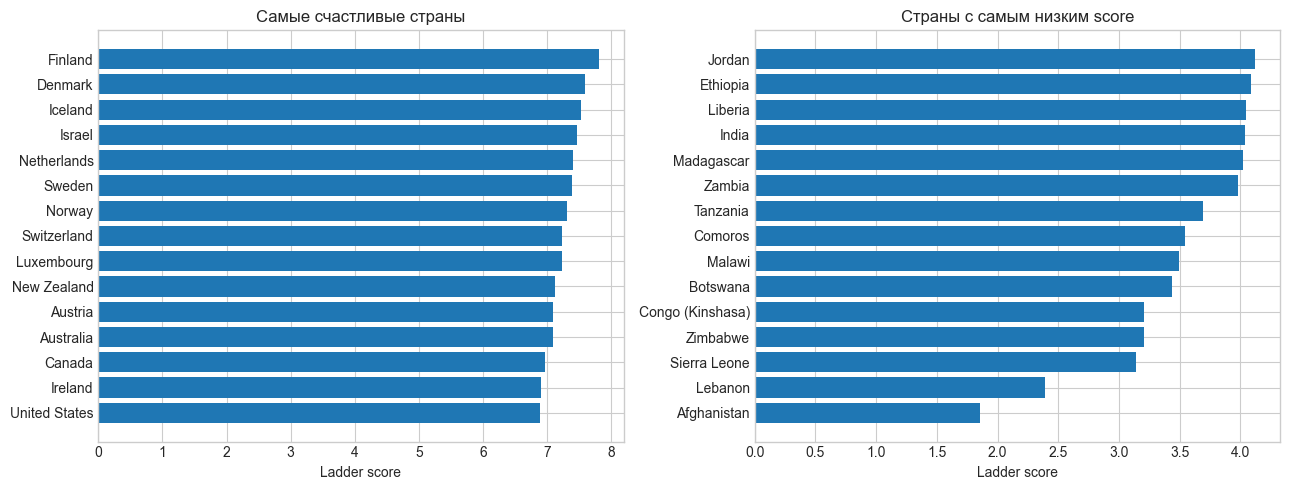

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ordered_top = data.nlargest(15, "ladder_score").sort_values("ladder_score")
ordered_bottom = data.nsmallest(15, "ladder_score").sort_values("ladder_score")

axes[0].barh(ordered_top["country"], ordered_top["ladder_score"])
axes[0].set_title("Самые счастливые страны")
axes[0].set_xlabel("Ladder score")

axes[1].barh(ordered_bottom["country"], ordered_bottom["ladder_score"])
axes[1].set_title("Страны с самым низким score")
axes[1].set_xlabel("Ladder score")

plt.tight_layout()

## Связи между показателями

In [8]:
correlation_matrix = data[numeric_columns].corr()
correlation_with_target = correlation_matrix["ladder_score"].drop("ladder_score").sort_values(key=np.abs, ascending=False)
correlation_with_target.to_frame("correlation_with_ladder_score")

,correlation_with_ladder_score
social_support,0.8381
logged_gdp_per_capita,0.7838
healthy_life_expectancy,0.7469
freedom_to_make_life_choices,0.6620
dystopia_residual,0.4945
perceptions_of_corruption,-0.4706
generosity,0.0398


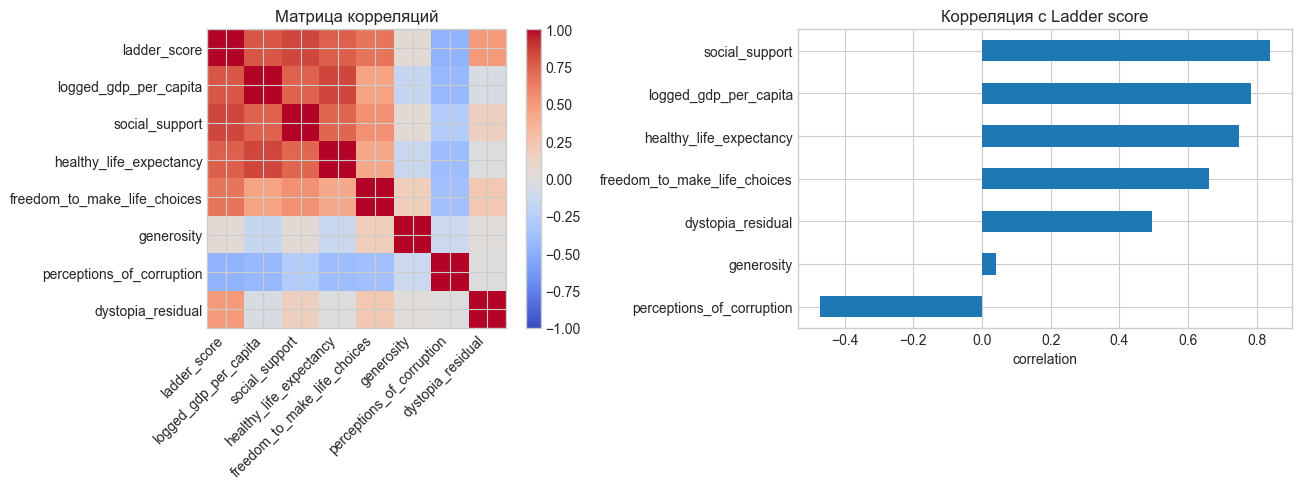

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

image = axes[0].imshow(correlation_matrix, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_xticks(range(len(numeric_columns)))
axes[0].set_yticks(range(len(numeric_columns)))
axes[0].set_xticklabels(numeric_columns, rotation=45, ha="right")
axes[0].set_yticklabels(numeric_columns)
axes[0].set_title("Матрица корреляций")

correlation_with_target.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Корреляция с Ladder score")
axes[1].set_xlabel("correlation")
axes[1].set_ylabel("")

fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)
plt.tight_layout()

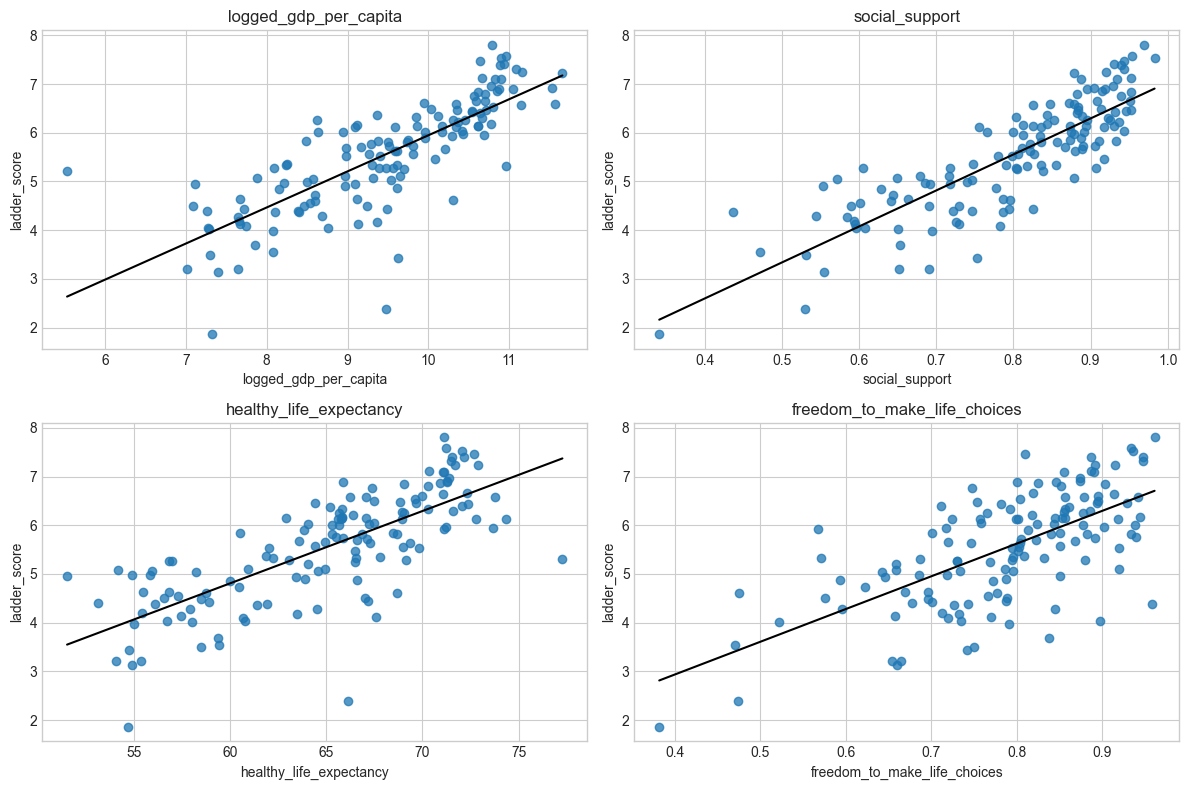

In [10]:
scatter_columns = [
    "logged_gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom_to_make_life_choices",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, column in zip(axes.ravel(), scatter_columns):
    axis.scatter(data[column], data["ladder_score"], alpha=0.75)
    slope, intercept = np.polyfit(data[column], data["ladder_score"], 1)
    x_line = np.linspace(data[column].min(), data[column].max(), 100)
    axis.plot(x_line, slope * x_line + intercept, color="black")
    axis.set_title(column)
    axis.set_xlabel(column)
    axis.set_ylabel("ladder_score")

plt.tight_layout()

## Линейная модель

In [11]:
target_name = "ladder_score"
feature_names = [
    "logged_gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom_to_make_life_choices",
    "generosity",
    "perceptions_of_corruption",
]

x = data[feature_names]
y = data[target_name]

x_with_constant = sm.add_constant(x)
ols_model = sm.OLS(y, x_with_constant).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           ladder_score   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     103.5
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           7.35e-47
Time:                        01:15:55   Log-Likelihood:                -90.929
No. Observations:                 136   AIC:                             195.9
Df Residuals:                     129   BIC:                             216.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.0802      0.713     -2.919      0.004      -3.490      -0.670
logged_gdp_per_capita            0.2026      0.071      2.844      0.005       0.062       0.344
social_support                   3.9230      0.559      7.019      0.000       2.817       5.029
healthy_life_expectancy          0.0201      0.014      1.434      0.154      -0.008       0.048
freedom_to_make_life_choices     2.3400      0.468      5.002      0.000       1.414       3.266
generosity                       0.1429      0.322      0.444      0.658      -0.494       0.780
perceptions_of_corruption       -0.7979      0.281     -2.840      0.005      -1.354      -0.242
==============================================================================
Omnibus:                       10.616   Durbin-Watson:                   1.841
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               10.844
Skew:                          -0.614   Prob(JB):                      0.00442
Kurtosis:                       3.638   Cond. No.                     1.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.31e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [12]:
coefficient_table = ols_model.summary2().tables[1]
coefficient_table.sort_values("P>|t|")

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
social_support,3.9230,0.5589,7.0192,1.1360e-10,2.8172,5.0288
freedom_to_make_life_choices,2.3400,0.4679,5.0015,1.8196e-06,1.4143,3.2657
const,-2.0802,0.7127,-2.9190,4.1453e-03,-3.4902,-0.6702
logged_gdp_per_capita,0.2026,0.0712,2.8436,5.1877e-03,0.0616,0.3436
perceptions_of_corruption,-0.7979,0.2809,-2.8404,5.2375e-03,-1.3537,-0.2421
healthy_life_expectancy,0.0201,0.0140,1.4343,1.5392e-01,-0.0076,0.0479
generosity,0.1429,0.3220,0.4438,6.5796e-01,-0.4942,0.7800


In [13]:
vif_table = pd.DataFrame(
    {
        "feature": x_with_constant.columns,
        "vif": [variance_inflation_factor(x_with_constant.values, index) for index in range(x_with_constant.shape[1])],
    }
)
vif_table.replace([np.inf, -np.inf], np.nan).sort_values("vif", ascending=False)

,feature,vif
0,const,293.8251
1,logged_gdp_per_capita,4.2691
3,healthy_life_expectancy,3.7336
2,social_support,3.0128
4,freedom_to_make_life_choices,1.5909
6,perceptions_of_corruption,1.4254
5,generosity,1.1939


In [14]:
residuals = ols_model.resid
fitted_values = ols_model.fittedvalues
bp_statistic, bp_pvalue, bp_fvalue, bp_fpvalue = het_breuschpagan(residuals, ols_model.model.exog)

diagnostics_table = pd.DataFrame(
    {
        "metric": ["r_squared", "adj_r_squared", "rmse", "mae", "shapiro_p_value", "breusch_pagan_p_value"],
        "value": [
            ols_model.rsquared,
            ols_model.rsquared_adj,
            mean_squared_error(y, fitted_values) ** 0.5,
            mean_absolute_error(y, fitted_values),
            st.shapiro(residuals).pvalue,
            bp_pvalue,
        ],
    }
)
diagnostics_table

,metric,value
0,r_squared,0.8280
1,adj_r_squared,0.8200
2,rmse,0.4722
3,mae,0.3596
4,shapiro_p_value,0.0055
5,breusch_pagan_p_value,0.0335


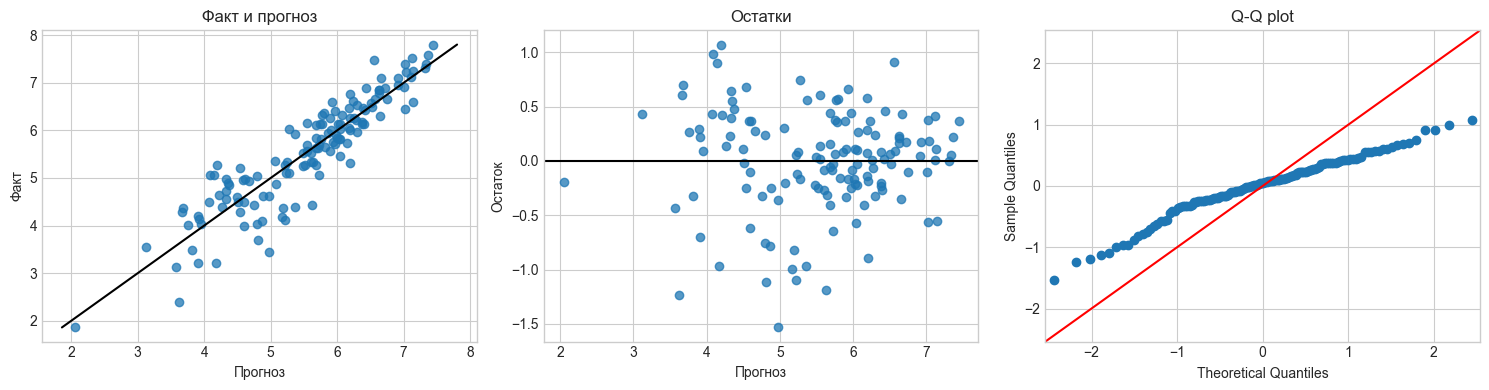

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(fitted_values, y, alpha=0.75)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], color="black")
axes[0].set_title("Факт и прогноз")
axes[0].set_xlabel("Прогноз")
axes[0].set_ylabel("Факт")

axes[1].scatter(fitted_values, residuals, alpha=0.75)
axes[1].axhline(0, color="black")
axes[1].set_title("Остатки")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Остаток")

sm.qqplot(residuals, line="45", ax=axes[2])
axes[2].set_title("Q-Q plot")

plt.tight_layout()

## Устойчивость модели

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "OLS": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 50))),
    "Lasso": make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, 1, 80), cv=cv, max_iter=30000, random_state=42)),
}

comparison_rows = []
for model_name, model in models.items():
    predicted = cross_val_predict(model, x, y, cv=cv)
    comparison_rows.append(
        {
            "model": model_name,
            "cv_r2": r2_score(y, predicted),
            "cv_rmse": mean_squared_error(y, predicted) ** 0.5,
            "cv_mae": mean_absolute_error(y, predicted),
        }
    )

model_comparison = pd.DataFrame(comparison_rows).sort_values("cv_rmse")
model_comparison

,model,cv_r2,cv_rmse,cv_mae
1,Ridge,0.8131,0.4922,0.3761
0,OLS,0.8115,0.4943,0.3769
2,Lasso,0.8110,0.4950,0.3787


In [17]:
best_model_name = model_comparison.iloc[0]["model"]
best_pipeline = models[best_model_name]
best_pipeline.fit(x, y)
linear_step_name = list(best_pipeline.named_steps.keys())[-1]
linear_step = best_pipeline.named_steps[linear_step_name]

standardized_coefficients = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": linear_step.coef_,
    }
).sort_values("coefficient")
standardized_coefficients

,feature,coefficient
5,perceptions_of_corruption,-0.1302
4,generosity,0.0275
2,healthy_life_expectancy,0.1586
0,logged_gdp_per_capita,0.2431
3,freedom_to_make_life_choices,0.2598
1,social_support,0.4336


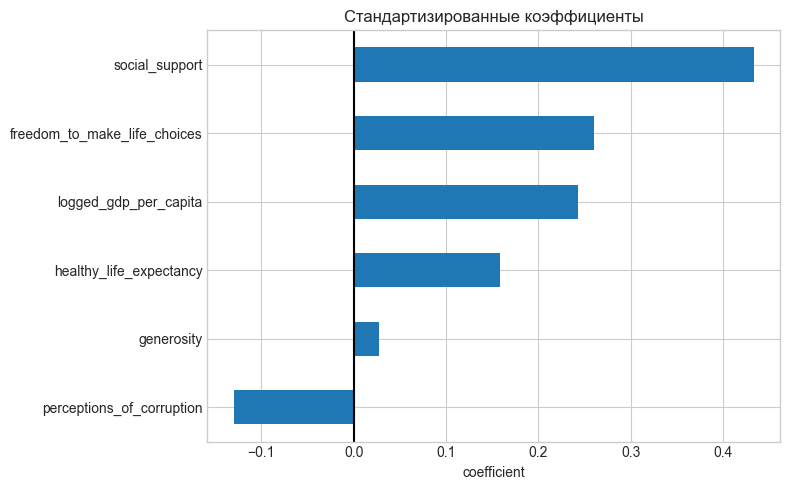

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
standardized_coefficients.plot(x="feature", y="coefficient", kind="barh", ax=ax, legend=False)
ax.axvline(0, color="black")
ax.set_title("Стандартизированные коэффициенты")
ax.set_xlabel("coefficient")
ax.set_ylabel("")
plt.tight_layout()

In [19]:
prediction_table = data[["country", "ladder_score"]].copy()
prediction_table["predicted_ladder_score"] = ols_model.predict(x_with_constant)
prediction_table["residual"] = prediction_table["ladder_score"] - prediction_table["predicted_ladder_score"]
prediction_table.reindex(prediction_table["residual"].abs().sort_values(ascending=False).index).head(15)

,country,ladder_score,predicted_ladder_score,residual
131,Botswana,3.435,4.9686,-1.5336
135,Lebanon,2.392,3.6277,-1.2357
111,Sri Lanka,4.442,5.6262,-1.1842
128,Tanzania,3.694,4.8129,-1.1189
122,Jordan,4.120,5.2212,-1.1012
85,Congo (Brazzaville),5.267,4.1946,1.0724
120,Egypt,4.170,5.1668,-0.9968
90,Guinea,5.072,4.0841,0.9879
133,Zimbabwe,3.204,4.1744,-0.9704
114,Cambodia,4.393,5.3624,-0.9694


## Вывод

Сильнее всего с уровнем счастья связаны социальная поддержка, доход, здоровье и свобода выбора. Линейная модель объясняет большую часть различий между странами, но остатки показывают страны, где фактический уровень счастья заметно выше или ниже прогноза по базовым факторам.